# Regression using Artificial Neural Networks

using the droped feature data set


In [60]:
# Import standard Libraries
import pandas as pd
import seaborn as sns
import altair as alt
import tensorflow as tf
import matplotlib.pyplot as plt


pd.set_option('display.float_format', '{:.4f}'.format)

sns.set(rc={'figure.figsize':(10,10)})
print("imports ok")

imports ok


##Load Data

In [61]:
# Load data file
data = pd.read_csv('C:\\Users\\DD\\Desktop\\IAAC\\DATA encoding\\final project_entropy prediction\\data\\processed\\dataset_dropped_features_clean.csv')
pd.options.display.max_columns = None

print(data)

      entropy_normalised  n_3way  n_deadend  proportion_4way  proportion_3way  \
0                 0.4445     109          7           0.6037           0.3375   
1                 0.4290     141          5           0.1913           0.7705   
2                 0.3901      72          0           0.6838           0.2846   
3                 0.4223     115          8           0.6618           0.2798   
4                 0.3950     111          3           0.6798           0.2913   
...                  ...     ...        ...              ...              ...   
2495              0.9459     112         49           0.1043           0.5308   
2496              0.9715      80         12           0.4408           0.3791   
2497              0.9543     163         15           0.1202           0.6996   
2498              0.9733     106          9           0.0748           0.7211   
2499              0.9511      59         15           0.1386           0.5842   

      proportion_deadend  m

In [62]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   entropy_normalised     2500 non-null   float64
 1   n_3way                 2500 non-null   int64  
 2   n_deadend              2500 non-null   int64  
 3   proportion_4way        2500 non-null   float64
 4   proportion_3way        2500 non-null   float64
 5   proportion_deadend     2500 non-null   float64
 6   mean_edge_length       2500 non-null   float64
 7   total_edge_length      2500 non-null   float64
 8   circuity               2500 non-null   float64
 9   distance_to_center_km  2500 non-null   float64
dtypes: float64(8), int64(2)
memory usage: 195.4 KB
None


In [63]:
for colname, col in data.items():
  print(colname, "min_val", col.min(), "max_val", col.max())

entropy_normalised min_val 0.383996 max_val 0.992793
n_3way min_val 9 max_val 881
n_deadend min_val 0 max_val 449
proportion_4way min_val 0.0 max_val 0.747922
proportion_3way min_val 0.115385 max_val 0.916667
proportion_deadend min_val 0.0 max_val 0.557692
mean_edge_length min_val 16.86 max_val 165.62
total_edge_length min_val 701.87 max_val 39750.52
circuity min_val 0.998254 max_val 1.445991
distance_to_center_km min_val 0.319 max_val 78.188


In [64]:
data.describe()

,entropy_normalised,n_3way,n_deadend,proportion_4way,proportion_3way,proportion_deadend,mean_edge_length,total_edge_length,circuity,distance_to_center_km
count,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000
mean,0.6921,105.0856,34.4676,0.2156,0.4949,0.1785,56.6371,14225.2829,1.0494,12.3641
std,0.1737,85.6122,37.0734,0.1777,0.1171,0.1077,20.8052,7873.8953,0.0500,10.3391
min,0.3840,9.0000,0.0000,0.0000,0.1154,0.0000,16.8600,701.8700,0.9983,0.3190
25%,0.5414,47.0000,12.0000,0.0833,0.4231,0.0949,40.5900,8223.5825,1.0164,5.8603
50%,0.6901,86.0000,23.0000,0.1634,0.5000,0.1667,52.0350,12638.5000,1.0366,9.7740
75%,0.8471,137.0000,43.2500,0.2926,0.5735,0.2500,67.6125,19096.2925,1.0640,14.7272
max,0.9928,881.0000,449.0000,0.7479,0.9167,0.5577,165.6200,39750.5200,1.4460,78.1880


In [65]:
print(data.columns.tolist())


['entropy_normalised', 'n_3way', 'n_deadend', 'proportion_4way', 'proportion_3way', 'proportion_deadend', 'mean_edge_length', 'total_edge_length', 'circuity', 'distance_to_center_km']


we can see that some predictors are binary, while others are not

In [66]:
feature_cols = ['n_3way', 'n_deadend', 'proportion_4way', 'proportion_3way',
                'proportion_deadend', 'mean_edge_length', 'total_edge_length',
                'circuity', 'distance_to_center_km']



print("Features:", feature_cols)
print("Target: entropy_normalised")
data[feature_cols].describe()


Features: ['n_3way', 'n_deadend', 'proportion_4way', 'proportion_3way', 'proportion_deadend', 'mean_edge_length', 'total_edge_length', 'circuity', 'distance_to_center_km']
Target: entropy_normalised


,n_3way,n_deadend,proportion_4way,proportion_3way,proportion_deadend,mean_edge_length,total_edge_length,circuity,distance_to_center_km
count,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000
mean,105.0856,34.4676,0.2156,0.4949,0.1785,56.6371,14225.2829,1.0494,12.3641
std,85.6122,37.0734,0.1777,0.1171,0.1077,20.8052,7873.8953,0.0500,10.3391
min,9.0000,0.0000,0.0000,0.1154,0.0000,16.8600,701.8700,0.9983,0.3190
25%,47.0000,12.0000,0.0833,0.4231,0.0949,40.5900,8223.5825,1.0164,5.8603
50%,86.0000,23.0000,0.1634,0.5000,0.1667,52.0350,12638.5000,1.0366,9.7740
75%,137.0000,43.2500,0.2926,0.5735,0.2500,67.6125,19096.2925,1.0640,14.7272
max,881.0000,449.0000,0.7479,0.9167,0.5577,165.6200,39750.5200,1.4460,78.1880


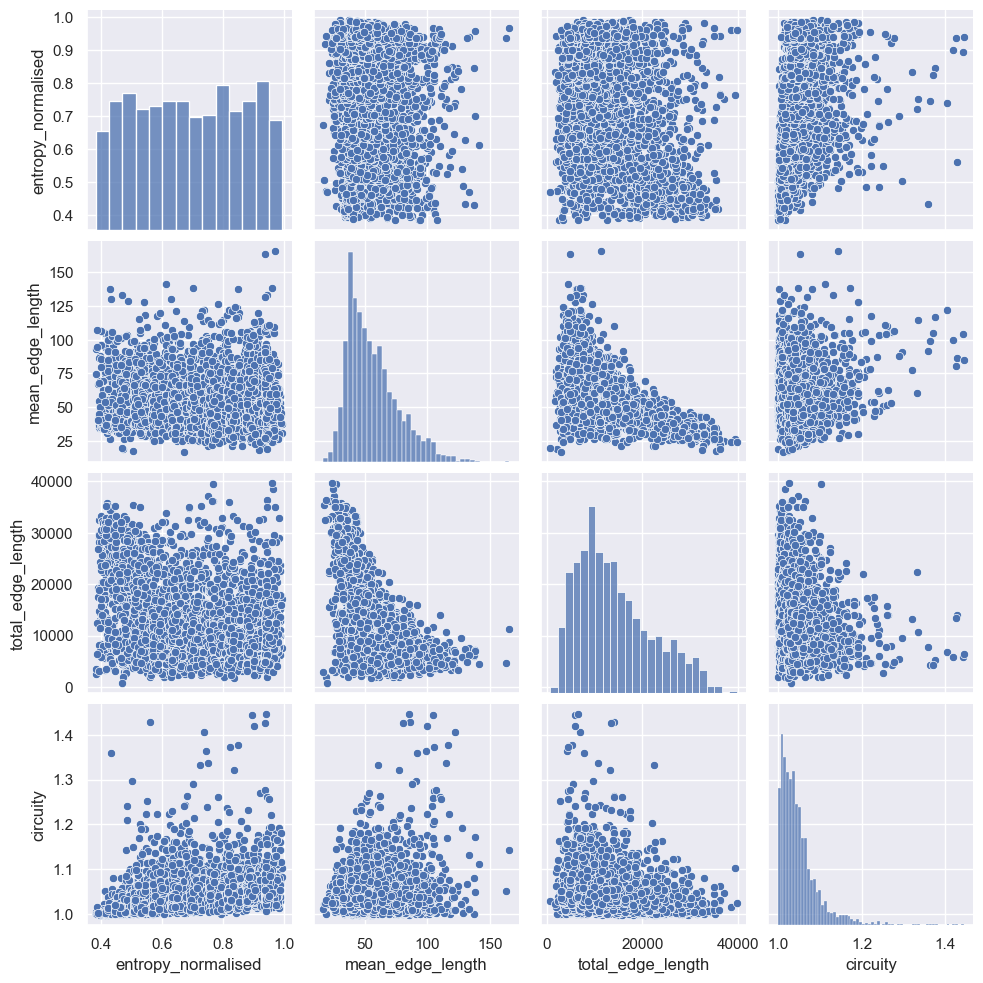

In [67]:
data_numerical = data[['entropy_normalised', 'mean_edge_length', 'total_edge_length', 'circuity']]
sns.pairplot(data_numerical)


We can see there is a direct relationship between age and experience, but not so much between wage and education, there is a non-linearity

##Prepare Data

**NORMALIZE INPUTS**

In [68]:
#same code as last time

feature_cols = ['n_3way', 'n_deadend', 'proportion_4way', 'proportion_3way',
                'proportion_deadend', 'mean_edge_length', 'total_edge_length',
                'circuity', 'distance_to_center_km']



X = data[feature_cols].to_numpy()

from sklearn.preprocessing import StandardScaler
scalerX = StandardScaler()

X_scaled = scalerX.fit_transform(X)

print(X_scaled.shape)


(2500, 9)


In [69]:
#declare regression target
y = data.loc[:, "entropy_normalised"].to_numpy()

y = y.reshape(-1, 1)

from sklearn.preprocessing import MinMaxScaler
scalerY = MinMaxScaler()

# Apply the scaler to our Y-features
y_scaled = scalerY.fit_transform(y)

print(y_scaled.shape)



(2500, 1)


**SPLIT INTO TRAIN AND TEST**

In [70]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size = 0.2, random_state = 21)

In [71]:
#visualize our data
#we can see that scikitlearn doesnt care if it is a dataframe or a numpy array, because they all function on the same way
print("TRAIN", "input", X_train.shape, "output", y_train.shape)
print("TEST", "input", X_test.shape, "output", y_test.shape)


TRAIN input (2000, 9) output (2000, 1)
TEST input (500, 9) output (500, 1)


#Build model

From the cheatSheet
Regression between 0 and 1>>
      activation = relu for hidden layers / sigmoid for final layer
      loss = mean squared error
      optimizer = adam
      input from data, is 8 columns
      output is 1 value prediction

In [72]:
# Instantiate a sequential model
model = tf.keras.models.Sequential()
n_cols = X_scaled.shape[1]

model.add(tf.keras.layers.Input(shape=(n_cols,)))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(32, activation='relu'))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='linear'))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
              loss='mean_squared_error')





In [73]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

#Train model

In [74]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=500, validation_split=0.2, callbacks=[early_stop])





Epoch 1/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2305 - val_loss: 0.0667
Epoch 2/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0873 - val_loss: 0.0556
Epoch 3/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0741 - val_loss: 0.0538
Epoch 4/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0665 - val_loss: 0.0485
Epoch 5/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0608 - val_loss: 0.0471
Epoch 6/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0563 - val_loss: 0.0473
Epoch 7/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0527 - val_loss: 0.0459
Epoch 8/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0525 - val_loss: 0.0447
Epoch 9/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0510 - val_loss: 0.0446
Epoch 10/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0477 - val_loss: 0.0441
Epoch 11/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0486 - val_loss: 0.0443
Epoch 12/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0

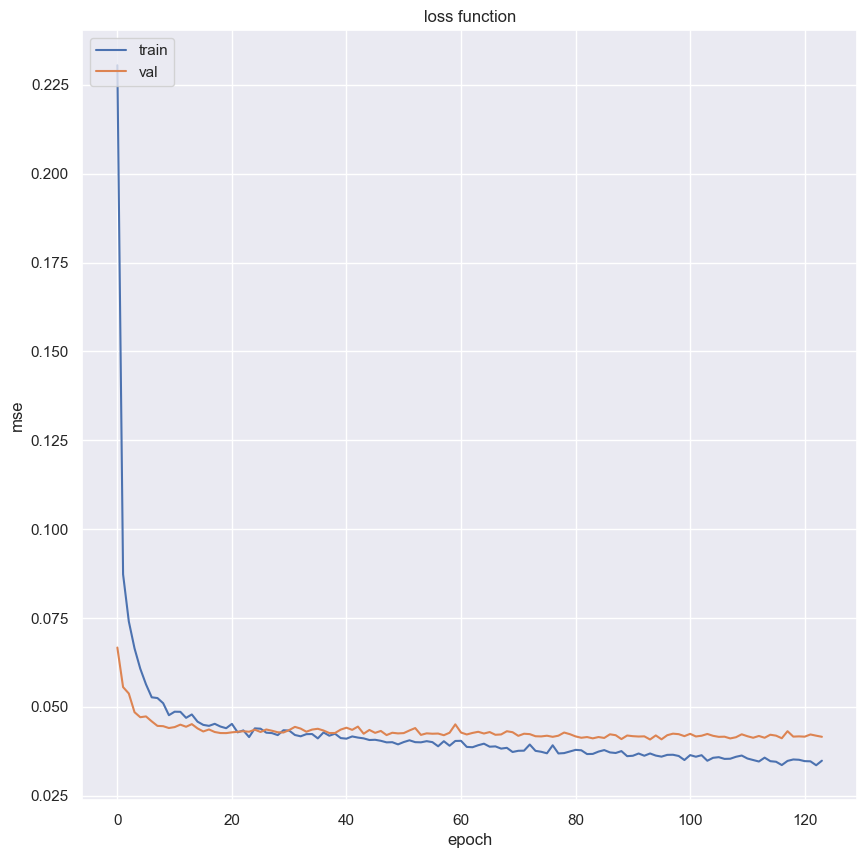

In [75]:
# summarize history for accuracy
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss function')
plt.ylabel('mse')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

#Evaluate model on test data



In [76]:
# Evaluate your model accuracy on the test data
loss_test = model.evaluate(X_test,y_test)

# Print accuracy
print('mse_test:', loss_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step - loss: 0.0389
mse_test: 0.03890443593263626


#Plot error


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


Text(0, 0.5, 'y_pred (entropy normalised)')

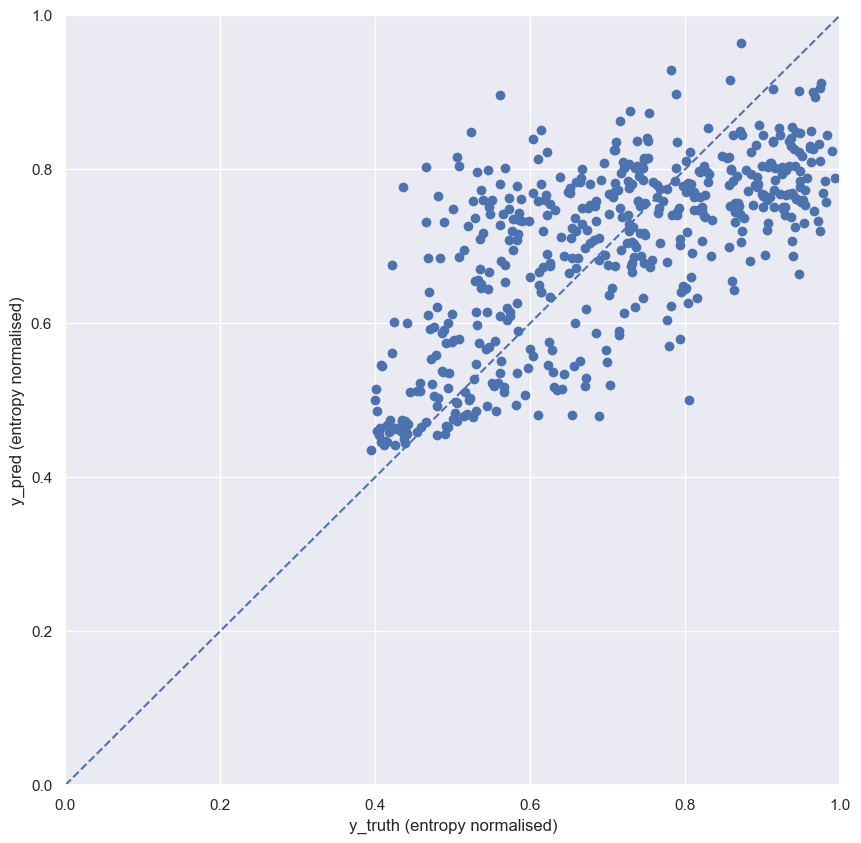

In [77]:
y_pred = scalerY.inverse_transform(model.predict(X_test))
y_truth = scalerY.inverse_transform(y_test)

plt.scatter(y_truth, y_pred)
plt.ylim((0, 1))
plt.xlim((0, 1))
plt.axline((0, 0), slope=1, ls="--")

plt.xlabel("y_truth (entropy normalised)")
plt.ylabel("y_pred (entropy normalised)")



In [78]:
from sklearn.metrics import r2_score
r2 = r2_score(y_truth, y_pred)
print(f'R² score: {r2:.4f}  →  model explains {r2*100:.1f}% of the variance')

R² score: 0.4885  →  model explains 48.8% of the variance


In [79]:
def plot_comparison(x_val, pred, truth, xlab, ylab):
  fig, ax1 = plt.subplots(figsize = (10,10))
  ax1.plot(x_val, truth, color = "red", label = "truth",linestyle='None', marker = "o", markersize = 5)
  ax1.plot(x_val, pred, color = "blue", label = "pred",linestyle='None', marker = "o", markersize = 4, alpha = 0.5)

  ax1.set_xlabel(xlab)
  ax1.set_ylabel(ylab)
  ax1.legend()
  plt.title('Prediction Comparison')
  plt.show()

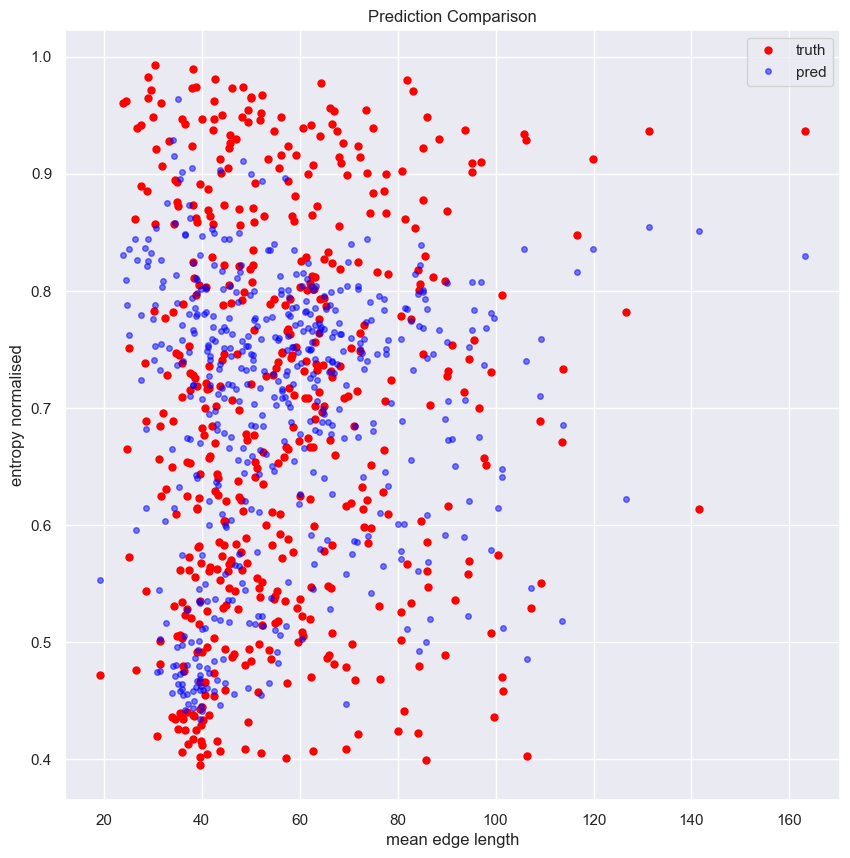

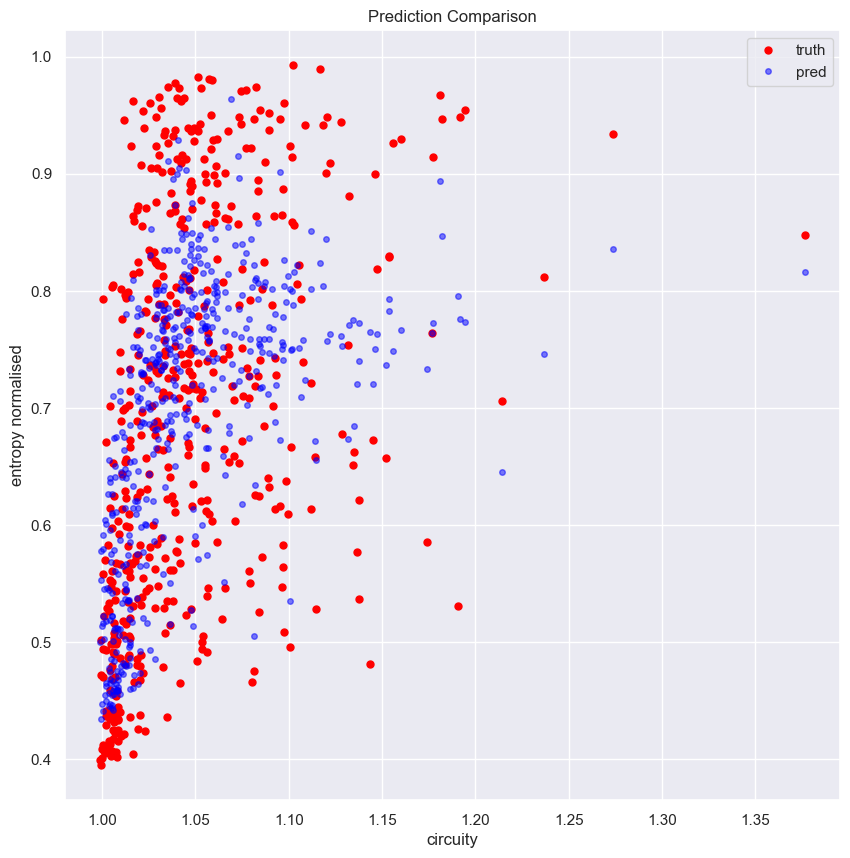

In [80]:
mean_edge_test = scalerX.inverse_transform(X_test)[:, feature_cols.index('mean_edge_length')]
circuity_test = scalerX.inverse_transform(X_test)[:, feature_cols.index('circuity')]

plot_comparison(mean_edge_test, y_pred, y_truth, "mean edge length", "entropy normalised")
plot_comparison(circuity_test, y_pred, y_truth, "circuity", "entropy normalised")


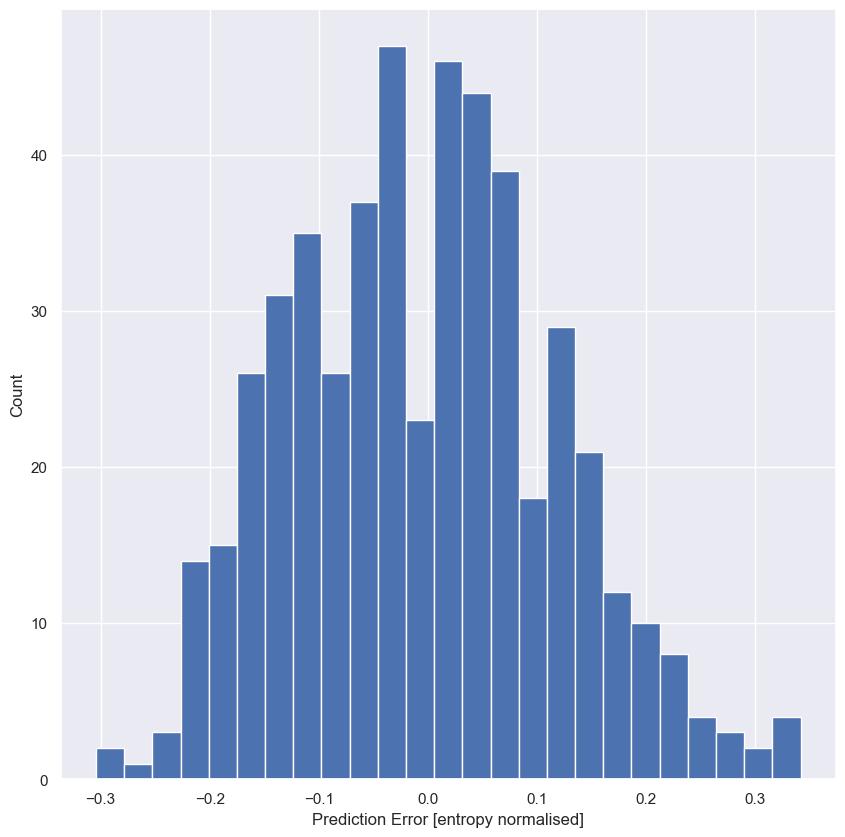

In [81]:
error = y_pred - y_truth
plt.hist(error, bins=25)
plt.xlabel('Prediction Error [entropy normalised]')
_ = plt.ylabel('Count')


In [82]:
model.save('ANNregression_02.keras')

import pickle
pickle.dump(scalerX, open('scalerX.pkl', 'wb'))
pickle.dump(scalerY, open('scalerY.pkl', 'wb'))

print("Model and scalers saved!")


Model and scalers saved!
